# 1. Gathering All the Data

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# 2. Performing Basic Exploratory Data Analysis (EDA)

In [3]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(50000, 2)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [5]:
print(df.describe())

                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
review       0
sentiment    0
dtype: int64


In [7]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
418


In [8]:
df = df.drop_duplicates()

In [9]:
print(df['sentiment'].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


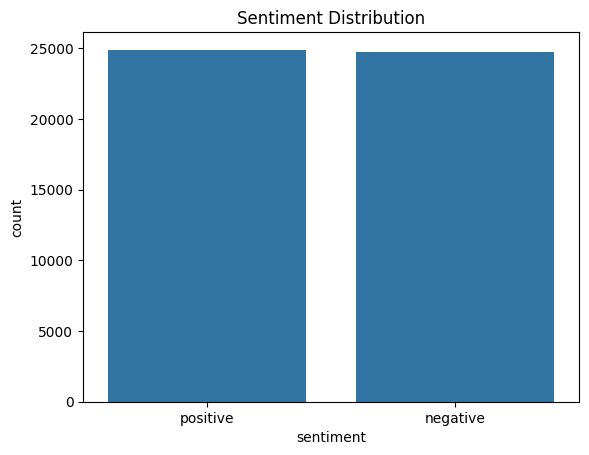

In [10]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()

In [11]:
df['review_length'] = df['review'].apply(len)

print(df['review_length'].describe())

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64


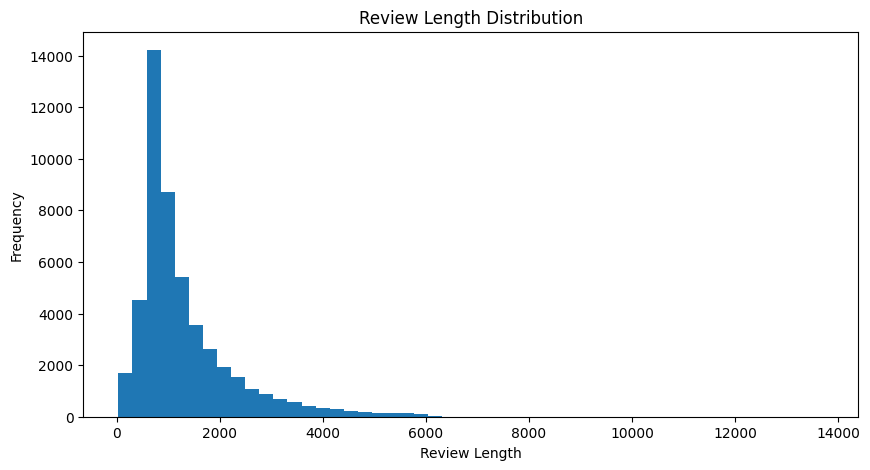

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df['review_length'], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

# 3. Perform Data Pre-processing

In [13]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
stop_words = set(stopwords.words('english'))

In [15]:
print(list(stop_words)[:20])

['some', "you're", 'haven', 'as', 'can', 'those', 'shan', 'i', 'or', 'at', "mustn't", "isn't", "don't", "they'd", 'was', 'will', 'which', "needn't", 'while', 'o']


# 4. Perform data cleaning and transformation

In [16]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\\S+|www\\S+', '', text)

    text = re.sub(r'\\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    cleaned_text = " ".join(tokens)

    return cleaned_text

In [17]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [18]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [19]:
stemmer = SnowballStemmer('english')

In [20]:
def stemming(text):

    text = " ".join(
        stemmer.stem(word)
        for word in text.split()
    )

    return text

In [21]:
df['cleaned_review'] = df['cleaned_review'].apply(stemming)
df.head()

,review,sentiment,review_length,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,1761,one review mention watch 1 oz episod youll hoo...
1,A wonderful little production. <br /><br />The...,positive,998,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,negative,748,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter mattei love time money visual stun film...


# 5. Finally create vectors using embedding model

In [22]:
from sentence_transformers import SentenceTransformer

In [23]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
embeddings = model.encode(
    df['cleaned_review'].tolist(),
    show_progress_bar=True
)
print(embeddings.shape)

Batches:   0%|          | 0/1550 [00:00<?, ?it/s]

(49582, 384)


In [25]:
print(embeddings[0])

[ 8.69123207e-04 -6.97617456e-02 -7.40762353e-02  3.28857936e-02
  2.91959196e-03  1.01903088e-01  4.89911176e-02 -1.23366097e-03
 -6.24961872e-03 -4.05401774e-02 -2.03501955e-02 -8.64544511e-02
 -2.52910778e-02 -1.45897614e-02 -2.88697332e-02 -5.13339825e-02
  1.28251016e-01 -1.79022904e-02 -5.19573316e-02  2.64206231e-02
  1.22754900e-02  1.18215000e-02  7.78455213e-02 -8.13207030e-03
 -5.53040244e-02  4.23924290e-02 -9.76662785e-02  2.72936225e-02
 -6.15392923e-02 -5.73349446e-02 -1.01198731e-02  8.03130940e-02
  1.92401968e-02  3.39235961e-02 -1.85323209e-02 -4.57800850e-02
  1.64054371e-02  8.74007791e-02  6.05673529e-02 -3.96490097e-02
 -4.74567898e-02  2.53041019e-03 -1.12778191e-02 -6.64699171e-03
  2.03514509e-02 -1.22297324e-01 -6.37192801e-02  4.55132034e-03
  2.49342043e-02 -2.01462973e-02 -8.43899474e-02 -2.97612716e-02
 -4.03406098e-03  4.65483665e-02 -6.18359074e-02 -5.66417202e-02
 -1.78288873e-02 -1.54790822e-02 -3.80843654e-02 -6.44206554e-02
 -1.43227912e-02 -2.16926

# VISUALIZING THE EMBEDDINGS

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(
    embeddings[:2000]
)

In [28]:
pca_df = pd.DataFrame()

pca_df['x'] = pca_embeddings[:,0]
pca_df['y'] = pca_embeddings[:,1]

pca_df['sentiment'] = df['sentiment'][:2000].values

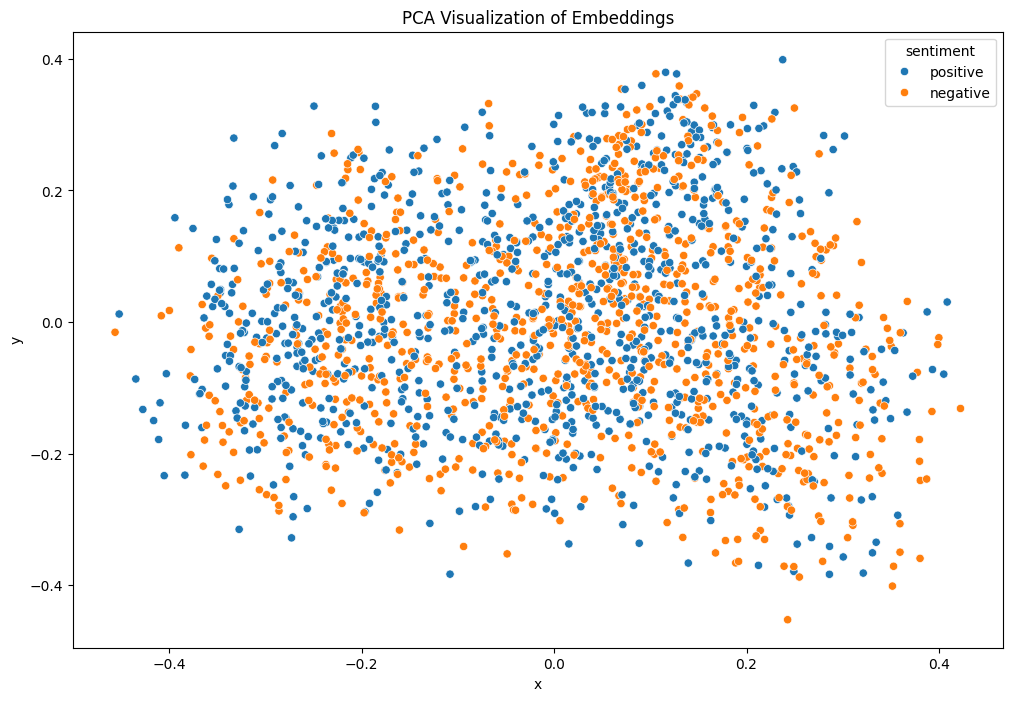

In [29]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x='x',
    y='y',
    hue='sentiment',
    data=pca_df
)

plt.title("PCA Visualization of Embeddings")

plt.show()

# Storing the vectors in Chroma DB

In [30]:
!pip install chromadb

In [31]:
import chromadb

client = chromadb.PersistentClient(
    path="./chroma_db"
)

collection = client.get_or_create_collection(
    name="imdb_movie_reviews"
)

ids = [str(i) for i in range(len(df))]

In [33]:
batch_size = 5000 # Choose a batch size less than the max_batch_size

for i in range(0, len(ids), batch_size):
    batch_ids = ids[i:i + batch_size]
    batch_embeddings = embeddings[i:i + batch_size].tolist()
    batch_documents = df['cleaned_review'][i:i + batch_size].tolist()
    batch_metadatas = [
        {"sentiment": sentiment}
        for sentiment in df['sentiment'][i:i + batch_size]
    ]

    collection.add(
        ids=batch_ids,
        embeddings=batch_embeddings,
        documents=batch_documents,
        metadatas=batch_metadatas
    )

print("All data added to ChromaDB collection.")

All data added to ChromaDB collection.


In [34]:
collection.count()

49582

In [35]:
query = "This movie was amazing and emotional"
query_embedding = model.encode([query])

results = collection.query(
    query_embeddings=query_embedding.tolist(),
    n_results=5
)

print(results)

{'ids': [['25602', '20541', '6328', '6570', '48054']], 'embeddings': None, 'documents': [['see jess jame quantril jayhawkersetc film fifti quit thrill see film new perspect director ang lee scene attack lawrenc kansa awesom romant relationship jewel tobi mcguir turn one best part jonathan rhysmey outstand bad guy time film make feel horror war desper situat main charact know go surviv next hour definit worth see', 'film absolut brilliant actual made think whole movi confus hell love everyth itit confus twist weird hard love actor phenomin one could done better jobthi one favorit yearit deserv ocar', 'nice see film real peopl honest feel sissi spacek absolut convinc simpl yet nice daughter robert farnsworthwho final last role get show fine actor hard believ david lynch film slow even sweet move one best unless like car chase sex scene violenc', 'saw trailer see film kinda feel felt like unsatisfi great movi dont get wrong think great part alreadi trailer catch drift went fast roll never

In [36]:
for i, review in enumerate(results['documents'][0]):

    print(f"Result {i+1}")
    print(review)
    print()

Result 1
see jess jame quantril jayhawkersetc film fifti quit thrill see film new perspect director ang lee scene attack lawrenc kansa awesom romant relationship jewel tobi mcguir turn one best part jonathan rhysmey outstand bad guy time film make feel horror war desper situat main charact know go surviv next hour definit worth see

Result 2
film absolut brilliant actual made think whole movi confus hell love everyth itit confus twist weird hard love actor phenomin one could done better jobthi one favorit yearit deserv ocar

Result 3
nice see film real peopl honest feel sissi spacek absolut convinc simpl yet nice daughter robert farnsworthwho final last role get show fine actor hard believ david lynch film slow even sweet move one best unless like car chase sex scene violenc

Result 4
saw trailer see film kinda feel felt like unsatisfi great movi dont get wrong think great part alreadi trailer catch drift went fast roll never bore enjoy watch humor absolut great first contact sloth som